In [1]:
import os
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [ ]:
# Define a custom Dataset for loading grayscale images and their labels
class GrayscaleDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0])
        image = Image.open(img_name).convert('L')  # Convert to grayscale
        label = int(self.data_frame.iloc[idx, 1])

        if self.transform:
            image = self.transform(image)
        return image, label

# Define a custom Dataset for loading grayscale images and their labels
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor()           # Convert images to tensors
])

# Specify the training image directory
root_dir = "/kaggle/input/aoi-data/train_images/train_images"

# Create the dataset and DataLoader
dataset = GrayscaleDataset(
    csv_file='/kaggle/input/aoi-data/train.csv',
    root_dir=root_dir,
    transform=transform
)
data_loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [3]:
# Example: Iterate through the DataLoader
for images, labels in data_loader:
    print(images.shape, labels.shape)  # images: [16, 1, 128, 128], labels: [16]
    break

torch.Size([16, 1, 128, 128]) torch.Size([16])


In [ ]:
# Define a simple VGG-like neural network
class VGG(nn.Module):
    def __init__(self, num_classes=6):
        super(VGG, self).__init__()
        self.features = nn.Sequential(
            # First Convolutional Block
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Second Convolutional Block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Third Convolutional Block
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)        # Extract features
        x = x.view(x.size(0), -1)   # Flatten the feature maps
        x = self.classifier(x)      # Classify using fully connected layers
        return x

# Set device for training (GPU if available, otherwise CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VGG(num_classes=6).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
# Training loop
epochs = 100
loss_history = []
for epoch in range(epochs):
    model.train()
    for images, labels in tqdm(data_loader, desc=f"training progress"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save the trained model
torch.save(model.state_dict(), "model_state.pth")

training progress: 100%|██████████| 158/158 [00:29<00:00,  5.30it/s]


Epoch [1/100], Loss: 1.9522


training progress: 100%|██████████| 158/158 [00:17<00:00,  8.84it/s]


Epoch [2/100], Loss: 1.6065


training progress: 100%|██████████| 158/158 [00:18<00:00,  8.77it/s]


...

Epoch [98/100], Loss: 0.1440


training progress: 100%|██████████| 158/158 [00:16<00:00,  9.41it/s]


Epoch [99/100], Loss: 0.0425


training progress: 100%|██████████| 158/158 [00:16<00:00,  9.43it/s]


Epoch [100/100], Loss: 0.0051


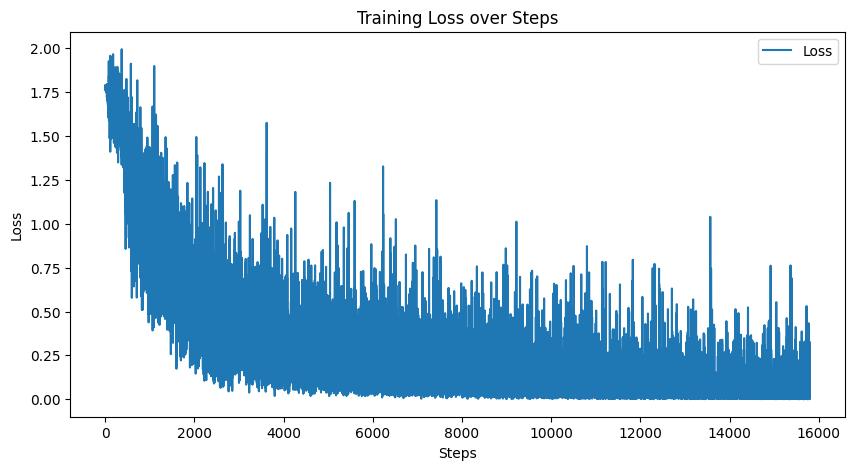

In [ ]:
# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.savefig(f'./training_loss.jpg')
plt.show()

In [ ]:
# Load model for evaluation
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VGG(num_classes=6).to(device)

load_path = '/kaggle/working/model_state.pth'
if load_path is not None:
    model.load_state_dict(torch.load(load_path, weights_only=True))
    model.eval()

In [ ]:
# Define a test dataset class
class TestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0])
        image = Image.open(img_name).convert('L')  # Convert to grayscale

        if self.transform:
            image = self.transform(image)

        return image, self.data_frame.iloc[idx, 0]  # Return image and its ID

# Create test DataLoader
root_dir_test = "/kaggle/input/aoi-data/test_images/test_images"
test_dataset = TestDataset(
    csv_file='/kaggle/input/aoi-data/test.csv',
    root_dir=root_dir_test,
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
# Perform inference
predictions = []
with torch.no_grad():
    for images, ids in tqdm(test_loader, desc=f"test evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(zip(ids, predicted.cpu().numpy()))

# Save predictions to a CSV file
output_df = pd.DataFrame(predictions, columns=['ID', 'Label'])
output_df.to_csv('./test_predictions.csv', index=False)

test evaluating: 100%|██████████| 634/634 [01:52<00:00,  5.62it/s]
